# Notebook 04 - Random Forest

**Objectif** : Entraîner un modèle Random Forest et comparer ses performances 
à la régression logistique (baseline AUC = 0.7485).

## 0. Imports et chargement des données prétraitées

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-darkgrid')

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Train : {X_train.shape[0]:,} lignes × {X_train.shape[1]} colonnes")
print(f"Test  : {X_test.shape[0]:,} lignes × {X_test.shape[1]} colonnes")

Train : 215,254 lignes × 212 colonnes
Test  : 92,253 lignes × 212 colonnes


## 1. Entraînement du Random Forest

Modèle avec class_weight='balanced', 200 arbres, et validation croisée 
à 3 folds pour évaluer la stabilité.

In [3]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Validation croisée sur le train (3 folds)
scores_cv = cross_val_score(model_rf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"AUC en validation croisée (3 folds) : {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")

# Entraînement sur tout le train
model_rf.fit(X_train, y_train)

# Prédictions
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

AUC en validation croisée (3 folds) : 0.7358 ± 0.0033


L'AUC en cross-validation (0.7358) est inférieure à celle de la régression logistique (0.7485).

## 2. Calcul des métriques

In [6]:
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
gini_rf = 2 * auc_rf - 1
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
ks_rf = max(tpr_rf - fpr_rf)


print("MÉTRIQUES : RANDOM FOREST")

print(f"AUC-ROC  : {auc_rf:.4f}")
print(f"Gini     : {gini_rf:.4f}")
print(f"KS       : {ks_rf:.4f}")

print("\n Comparaison avec la baseline ")
print(f"AUC Régression logistique : 0.7485")
print(f"AUC Random Forest         : {auc_rf:.4f}")
print(f"Écart                     : {auc_rf - 0.7485:+.4f}")

MÉTRIQUES : RANDOM FOREST
AUC-ROC  : 0.7390
Gini     : 0.4779
KS       : 0.3546

 Comparaison avec la baseline 
AUC Régression logistique : 0.7485
AUC Random Forest         : 0.7390
Écart                     : -0.0095


Le Random Forest fait moins bien que la régression logistique (-0.95 point d'AUC). Cela montre qu'un modèle plus complexe ne gagne pas automatiquement.

## 3. Feature importance native

In [7]:
importances = pd.Series(model_rf.feature_importances_, index=X_train.columns)
top_20_rf = importances.sort_values(ascending=False).head(20)

print("Top 20 des variables les plus importantes (Random Forest) :\n")
for var, imp in top_20_rf.items():
    print(f"  {var:45s} → {imp:.4f}")

Top 20 des variables les plus importantes (Random Forest) :

  EXT_SOURCE_2                                  → 0.0635
  EXT_SOURCE_3                                  → 0.0627
  AGE                                           → 0.0307
  DAYS_BIRTH                                    → 0.0301
  DAYS_ID_PUBLISH                               → 0.0295
  EXT_SOURCE_1                                  → 0.0288
  DAYS_REGISTRATION                             → 0.0286
  DAYS_LAST_PHONE_CHANGE                        → 0.0285
  AMT_ANNUITY                                   → 0.0283
  DAYS_EMPLOYED                                 → 0.0279
  EMPLOYMENT_YEARS                              → 0.0274
  ANNUITY_INCOME_RATIO                          → 0.0274
  CREDIT_INCOME_RATIO                           → 0.0273
  AMT_CREDIT                                    → 0.0270
  AMT_GOODS_PRICE                               → 0.0251
  REGION_POPULATION_RELATIVE                    → 0.0231
  AMT_INCOME_TOTAL         

Le classement est complètement différent de celui de la régression logistique. Les deux modèles ne voient pas les mêmes variables comme importantes

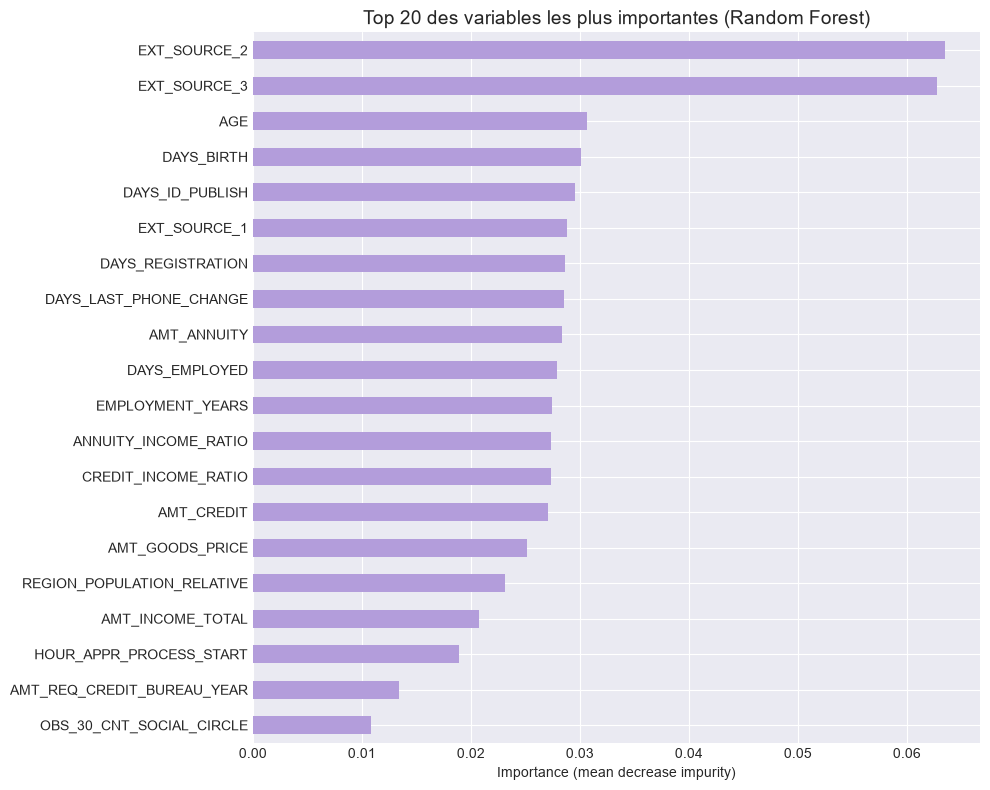

In [8]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
top_20_rf.sort_values().plot(kind='barh', color='#B39DDB', ax=ax)
ax.set_title("Top 20 des variables les plus importantes (Random Forest)", fontsize=14)
ax.set_xlabel("Importance (mean decrease impurity)")

plt.tight_layout()
plt.savefig("../outputs/figures/11_feature_importance_rf.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Synthèse

### Résultats du Random Forest

- **AUC-ROC** : 0.7390
- **Gini** : 0.4779
- **KS** : 0.3546
- **AUC en validation croisée** : 0.7358 ± 0.0033

### Comparaison avec la baseline

Le Random Forest fait légèrement moins bien que la régression logistique 
(AUC 0.7390 vs 0.7485, soit -0.95 point). Ce résultat, bien que contre-intuitif, 
n'est pas rare en scoring de crédit, la régression logistique reste compétitive 
sur des données tabulaires prétraitées (Lessmann et al., 2015).

### Observation sur les variables importantes

Le classement des variables diffère fortement entre les deux modèles. 
Le Random Forest place les EXT_SOURCE et l'âge en tête, tandis que la 
régression logistique privilégiait les FLAG_DOCUMENT et les variables 
catégorielles. Cette divergence sera à comparer avec l'analyse SHAP 
sur XGBoost.